# ARCH 509: AAAO

## Particle Swarm Opitmization 
### Nick Grosh

In [26]:
import numpy as np
import pandas as pd
import math
from numpy.random import uniform as u
import matplotlib.pyplot as plt
from copy import deepcopy
from time import sleep
import csv

In [27]:
#with open('variables.csv', 'w', newline='') as csvfile:
    #writer = csv.writer(csvfile)
#with open('fitness.csv', 'w', newline='') as csvfile:
    #writer = csv.writer(csvfile)

In [28]:
#objective function = a benchmark function
#test function for optimization 

#update this function when changing code to be our cost function 
def GHcostFunction(x):
    #part 1 from python to GH
    df = pd.DataFrame(x)
    print(df)
    df.to_csv('variables.csv')
    
    #wait 10 sec for calculation for GH
    sleep(100)
    
    #part 2 from GH to python
    fitness = pd.read_csv ('fitness.csv')
    print('Fitness')
    print(fitness.values[0][0])
    
    return fitness.values[0][0]
#1 Rastrigin Function
def rastrigin (x):
    d = len(x)
    return 10 * d + np.sum(x**2 - 10 * np.cos(2 * np.pi * x))

#2 Rosenbrock function
def rosenbrock(x):
    d = len(x)
    return np.sum(100 * (x[1:] - x[:-1])**2 + (x[:-1] - 1) **2)

In [29]:
# Hyper parameters
n_iterations = 2
n_dimentions = 4 # Particle dimention (like gene??!)
bound_up = 3
bound_lw = -3
domain = bound_up - bound_lw
swarm_size = 3

#velocity 
vel_max = domain/10 #control the exploration vs exploitation
vel_min = - vel_max

costFunction = GHcostFunction # function to opitmize 

phi1 = 2.05
phi2 = 2.05
phi = phi1 + phi2
#rule of thumb phi1 + phi2 = 4.1 WHY WHAT? I HAVE NO CLUE
chi = 2/(phi - 2 + math.sqrt(phi**2 - 4 * phi))

#movment coeffcients
w = chi #interia weight / coeffceint 
c1 = chi * phi1 #cognitive weight
c2 = chi * phi2 #social weight

In [30]:
print('w = ', w)
print('c1 = ', c1)
print('c2 = ', c2)


w =  0.7298437881283576
c1 =  1.496179765663133
c2 =  1.496179765663133


In [31]:
class Particle:
    def __init__(self):
        self.position = u(bound_lw, bound_up, size = n_dimentions) # paritcle postion at start randomly 
        self.velocity = u(-domain, domain, size = n_dimentions) # particel velocity randomly
        self.pbest_position = deepcopy(self.position) # particle best position 
        self.pbest_cost = self.cost # best claue of the paritcle 
        
    @property
    def cost(self):
        return costFunction(self.position) # calculate the cost of the particel
    
    def update(self):
        #X_new = X_previous + V_new
        #Venew = w * V_previous + c1*r1*(p_best = X_previous) + c2*r2(gbest = X_previous)
        
        r1 = u(0,1, size = n_dimentions)
        r2 = u(0,1, size = n_dimentions)
        
        #personal & global learning coeffcients
        p_co = c1*r1
        g_co = c2*r2
        
        #update velocity 
        self.velocity = w*self.velocity + p_co*(self.pbest_position - self.position) + g_co*(gbest_position - self.position)
        
        #check the velocity components bound
        self.velocity[self.velocity < vel_min] = vel_min
        self.velocity[self.velocity > vel_max] = vel_max
        
        #update the positionn
        self.position += self.velocity 
        
        #velocity mirroring 
        self.velocity = np.where (self.position < bound_lw, -self.velocity, self.velocity)
        self.velocity = np.where (self.position > bound_up, -self.velocity, self.velocity)
        #Hint: np.wehre(conditon a,b) means where the conditon is tre put a otherwise put b
        
        #check the posisiton bounds
        self.position[self.position < bound_lw] = bound_lw
        self.position[self.position > bound_up] = bound_up
        
        if self.cost < self.pbest_cost:
            self.pbest_position = deepcopy(self.position)
            self.pbest_cost = self.cost

In [ ]:
#define Swarm Population 
particles = [Particle() for __ in range(swarm_size)]

def global_best():
    g_best = deepcopy(sorted(particles, key=lambda t:t.pbest_cost)[0])
    #sort particles based on the pbest cost therfore first item is the global best
    
    global gbest_cost, gbest_position 
    gbest_cost = g_best.pbest_cost
    gbest_position = g_best.pbest_position
    
#define two empty lists to record the best solution in each loop
best_positions = []
best_costs = []

          0
0  0.807870
1 -1.888163
2 -2.945116
3  1.238117
Fitness
0.872596
          0
0 -1.421940
1  0.300041
2 -2.797329
3  1.686136


In [ ]:
#to test the code so far!
global_best()
gbest_cost
gbest_position

array([0.94604046, 0.85756493, 0.75918742, 0.70019093])

          0
0  1.000000
1  0.757565
2  0.659187
3  0.800191
Fitness
0.872596
          0
0  0.180173
1  0.402420
2  0.640984
3  0.859262
Fitness
0.872596
iteration 0 best cost 0.872596
best_position [0.94604046 0.85756493 0.75918742 0.70019093]
----------------------------------------------------------------------------------------------------


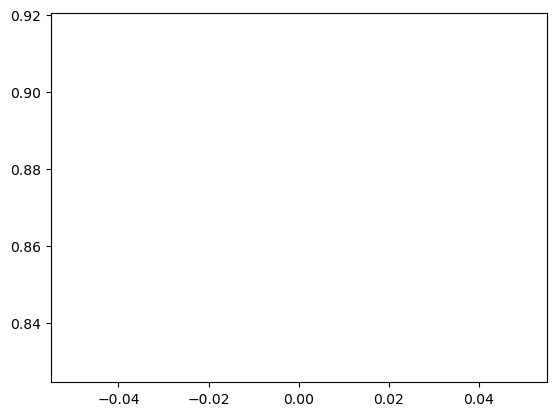

In [ ]:
for it in range(n_iterations):
    for particle in particles:
        particle.update()
    global_best()
    best_costs.append(gbest_cost)
    best_positions.append(gbest_position)

    #print the resutls of each loop
    print('iteration', it, 'best cost', best_costs[-1])
    print('best_position', best_positions[-1])
    print("-"*100)
    
plt.plot(best_costs)
plt.show()